In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from achest import MarketDataClient
import pandas as pd
client = MarketDataClient("https://achestv2.misango.me")

In [ ]:
data = client.options(
    ["XAUUSD"],
    "2026-09-21",        # start (Sunday — won't matter)
    "2026-09-23",        # end = day AFTER last trading day you want
    "daily",
)

AttributeError: 'MarketDataClient' object has no attribute 'options_data'

In [3]:
df = pd.json_normalize(data)

In [4]:
# 3. Separate calls and puts for precise tracking
calls = df[df['type'] == 'call'].sort_values('strike')
puts = df[df['type'] == 'put'].sort_values('strike')

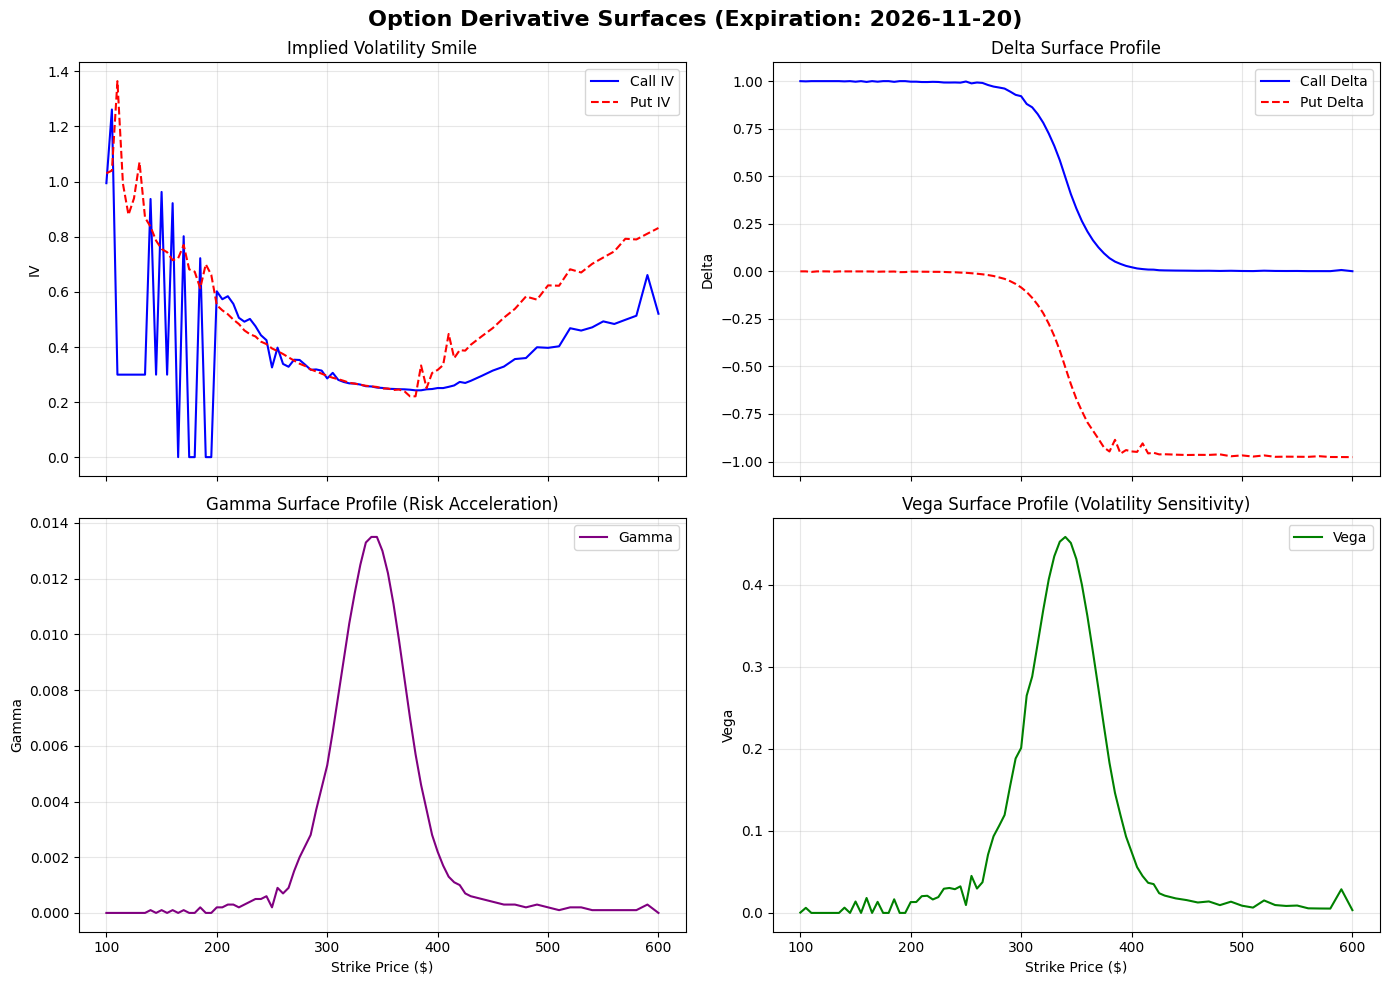

In [7]:
# 4. Initialize a 2x2 plotting dashboard
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle(
    'Option Derivative Surfaces (Expiration: 2026-11-20)',
    fontsize=16,
    fontweight='bold',
)

# Panel 1: Implied Volatility (The Volatility Smile)
axs[0, 0].plot(calls['strike'], calls['impliedVol'], label='Call IV', color='blue')
axs[0, 0].plot(puts['strike'], puts['impliedVol'], label='Put IV', color='red', linestyle='--')
axs[0, 0].set_title('Implied Volatility Smile')
axs[0, 0].set_ylabel('IV')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Panel 2: Delta Surface
axs[0, 1].plot(calls['strike'], calls['greeks.delta'], label='Call Delta', color='blue')
axs[0, 1].plot(puts['strike'], puts['greeks.delta'], label='Put Delta', color='red', linestyle='--')
axs[0, 1].set_title('Delta Surface Profile')
axs[0, 1].set_ylabel('Delta')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# Panel 3: Gamma Surface
axs[1, 0].plot(calls['strike'], calls['greeks.gamma'], label='Gamma', color='purple')
axs[1, 0].set_title('Gamma Surface Profile (Risk Acceleration)')
axs[1, 0].set_xlabel('Strike Price ($)')
axs[1, 0].set_ylabel('Gamma')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# Panel 4: Vega Surface
axs[1, 1].plot(calls['strike'], calls['greeks.vega'], label='Vega', color='green')
axs[1, 1].set_title('Vega Surface Profile (Volatility Sensitivity)')
axs[1, 1].set_xlabel('Strike Price ($)')
axs[1, 1].set_ylabel('Vega')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import requests

# 1. Pull the structural array data from your verified endpoint

headers = {
    'Accept': 'application/json',
}

response = requests.get('https://api.eulerpool.com/api/1/derivatives/options/iv-surface/US0378331005?token=eu_prod_1789005743341_iniyxnq3wek', headers=headers)
data = response.json()

# Extract parameters
ticker = data['ticker']
spot_price = data['spot']
expirations = data['expirations']
strikes = data['strikes']
surface_matrix = data['surface']

# 2. Parse into Days to Expiration (DTE) using your October 8, 2026 coordinate
anchor_date = pd.to_datetime('2026-10-08')
dtes = [(pd.to_datetime(exp) - anchor_date).days for exp in expirations]

# 3. Restructure the raw nested arrays into a flattened tabular model
records = []
for i, dte in enumerate(dtes):
    for j, strike in enumerate(strikes):
        iv_value = surface_matrix[i][j]
        # Ignore dead coordinates or unpopulated options nodes
        if iv_value is not None:
            records.append({'DTE': dte, 'Strike': strike, 'IV': iv_value})

df_surface = pd.DataFrame(records)

# 4. Apply Strike bounding window around Spot ($336.67) to view the actual smile shape
# Prevents extreme out-of-the-money values (like $5) from washing out the visual range
lower_bound = spot_price * 0.65  # approx $220
upper_bound = spot_price * 1.35  # approx $455

df_filtered = df_surface[
    (df_surface['Strike'] >= lower_bound) & 
    (df_surface['Strike'] <= upper_bound)
]

# 5. Build the continuous 2D rectangular surface mesh grid matrix
surface_pivot = df_filtered.pivot_table(index='DTE', columns='Strike', values='IV')

# Interpolate any sparse data intersections to prevent empty holes in the surface mesh
surface_pivot = surface_pivot.interpolate(method='linear', axis=1).fillna(method='bfill')

# Extract plotting arrays
X_axis = surface_pivot.columns.values
Y_axis = surface_pivot.index.values
Z_axis = surface_pivot.values

# 6. Generate the Interactive 3D Canvas
# 6. Generate the Interactive 3D Canvas
fig = go.Figure(data=[go.Surface(
    x=X_axis,
    y=Y_axis,
    z=Z_axis,
    colorscale='Viridis',
    colorbar=dict(
        title=dict(
            text='Implied Vol (IV)',
            side='top'  # <--- Correct Plotly nested title alignment syntax
        )
    )
)])

fig.update_layout(
    title=dict(
        text=f"<b>{ticker} Implied Volatility Surface</b><br>Spot Anchor: ${spot_price:,.2f} | Reference: Oct 8, 2026",
        x=0.5,
        xanchor='center'
    ),
    scene=dict(
        xaxis=dict(title='Strike Price ($)', gridcolor='rgba(0,0,0,0.1)'),
        yaxis=dict(title='Days to Expiration (DTE)', gridcolor='rgba(0,0,0,0.1)'),
        zaxis=dict(title='Implied Volatility (IV)', gridcolor='rgba(0,0,0,0.1)')
    ),
    margin=dict(l=10, r=10, b=10, t=80),
    width=950,
    height=650
)

# Opens the interactive graph canvas directly inside your web browser
fig.show()



/var/folders/l8/x6h41g5n1l58tbdctr84ly4h0000gn/T/ipykernel_20686/2123349651.py:51: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  surface_pivot = surface_pivot.interpolate(method='linear', axis=1).fillna(method='bfill')
